# Acoustic Modal Analysis: pyCAFE vs FEniCSx

**Problem:** 2D rectangular cavity, 1 m × 0.5 m, filled with air (c₀ = 343 m/s, ρ = 1.204 kg/m³).  
**Boundary conditions:** all hard walls (Neumann: ∂p/∂n = 0).  
**Eigenvalue problem:** K φ = λ M φ, with λ = ω² = (2πf)².

**Analytical solution** for all-Neumann rectangular cavity:
$$f_{m,n} = \frac{c_0}{2}\sqrt{\left(\frac{m}{L_x}\right)^2 + \left(\frac{n}{L_y}\right)^2}, \quad m,n = 0,1,2,\ldots$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time

# --- Problem parameters ---
Lx   = 1.0    # m
Ly   = 0.5    # m
c0   = 343.0  # m/s  (air)
rho  = 1.204  # kg/m³
NUM_MODES = 6

# --- Analytical frequencies ---
def analytical_freqs(Lx, Ly, c0, n_max=6):
    freqs = []
    for m in range(8):
        for n in range(8):
            if m == 0 and n == 0:
                continue
            f = (c0 / 2) * np.sqrt((m / Lx)**2 + (n / Ly)**2)
            freqs.append((f, m, n))
    freqs.sort()
    return freqs[:n_max]

freqs_ref = analytical_freqs(Lx, Ly, c0, NUM_MODES)
print("=== Analytical frequencies ===")
print(f"{'Mode (m,n)':>12}  {'f [Hz]':>12}")
print("-" * 28)
for f, m, n in freqs_ref:
    print(f"  ({m},{n}){' ':>6}  {f:>12.4f}")

=== Analytical frequencies ===
  Mode (m,n)        f [Hz]
----------------------------
  (1,0)            171.5000
  (0,1)            343.0000
  (2,0)            343.0000
  (1,1)            383.4857
  (2,1)            485.0753
  (3,0)            514.5000


---
## 1 — pyCAFE
Uses serendipity CQUAD8 elements (8-node quadrilateral, order 2).

Info    : Reading 'rectangle_CQUAD8.msh'...
Info    : 9 entities
Info    : 6337 nodes
Info    : 2240 elements
Info    : Done reading 'rectangle_CQUAD8.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 192
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 2048

Available boundary names in the mesh:
-------------------------------------
- bottom               | 127 nodes
- right                | 63 nodes
- top                  | 127 nodes
- left                 | 63 nodes


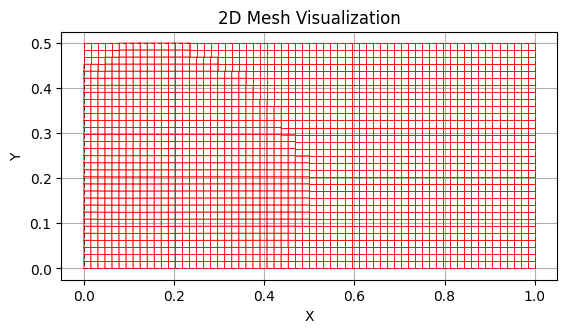

Detected acoustic element type: CQUAD8


pyCAFE  | DOF: 6337  | Time: 2.764 s

  Mode     f_pyCAFE [Hz]      f_ref [Hz]     error [%]
------------------------------------------------------
  (1,0)          171.5000        171.5000       0.0000%
  (0,1)          343.0000        343.0000       0.0000%
  (2,0)          343.0000        343.0000       0.0000%
  (1,1)          383.4857        383.4857       0.0000%
  (2,1)          485.0753        485.0753       0.0000%
  (3,0)          514.5002        514.5000       0.0000%


In [2]:
import pycafe
from pycafe.solver.solver_modale import solve_modal_acoustic_reduced
from pycafe.build_matrices.assembly_cquad8 import expand_mode_to_full

MESH_FILE = "rectangle_CQUAD8.msh"

t0 = time.perf_counter()

# Load
fluid  = pycafe.load_fluid("air")
nodes, elements, boundaries = pycafe.load_mesh(MESH_FILE)

# All hard walls → no Dirichlet nodes
bc = ([], [], 0.0, [], 0.0+0j, [], 0.0, None, 0.0)

# Assemble
system = pycafe.prepare_acoustic_system(
    nodes=nodes, elements=elements, boundaries=boundaries,
    rho=fluid["rho"], c0=fluid["c0"], bc=bc, debug=False,
)
K_red = system["K_red"]
M_red = system["M_red"]

# Solve
freqs_cafe, modes_cafe = solve_modal_acoustic_reduced(K_red, M_red, num_modes=NUM_MODES)

t_cafe = time.perf_counter() - t0

n_dof_cafe = K_red.shape[0]
print(f"pyCAFE  | DOF: {n_dof_cafe}  | Time: {t_cafe:.3f} s")
print(f"\n{'Mode':>6}  {'f_pyCAFE [Hz]':>16}  {'f_ref [Hz]':>14}  {'error [%]':>12}")
print("-" * 54)
for i, (f_ref, m, n) in enumerate(freqs_ref):
    err = abs(freqs_cafe[i] - f_ref) / f_ref * 100
    print(f"  ({m},{n})  {freqs_cafe[i]:>16.4f}  {f_ref:>14.4f}  {err:>11.4f}%")

---
## 2 — FEniCSx (dolfinx)
Uses standard Lagrange Q2 elements on a structured quad mesh with the same element density.

In [3]:
from mpi4py import MPI
import dolfinx
from dolfinx import mesh as dmesh, fem
from dolfinx.fem import functionspace
from dolfinx.fem.petsc import assemble_matrix as petsc_assemble_matrix
import ufl
from petsc4py import PETSc
from slepc4py import SLEPc

# Match pyCAFE mesh density: 2048 CQUAD8 → 64 x 32 structured Q2 mesh
Nx, Ny = 64, 32

t0 = time.perf_counter()

# --- Mesh ---
msh = dmesh.create_rectangle(
    MPI.COMM_WORLD,
    [[0.0, 0.0], [Lx, Ly]],
    [Nx, Ny],
    cell_type=dmesh.CellType.quadrilateral,
)

# --- Function space: Lagrange Q2 ---
V = functionspace(msh, ("Lagrange", 2))
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# --- Bilinear forms ---
# K: stiffness  ∫ ∇u · ∇v dΩ
# M: mass       ∫ (1/c0²) u v dΩ
a_K = ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx
a_M = (1.0 / c0**2) * ufl.inner(u, v) * ufl.dx

# --- Assemble ---
K_form = fem.form(a_K)
M_form = fem.form(a_M)

K_mat = petsc_assemble_matrix(K_form)
K_mat.assemble()
M_mat = petsc_assemble_matrix(M_form)
M_mat.assemble()

n_dof_fenics = V.dofmap.index_map.size_global * V.dofmap.index_map_bs

# --- SLEPc eigenvalue solver ---
eps = SLEPc.EPS().create(MPI.COMM_WORLD)
eps.setOperators(K_mat, M_mat)
eps.setProblemType(SLEPc.EPS.ProblemType.GHEP)  # generalised Hermitian
eps.setWhichEigenpairs(SLEPc.EPS.Which.SMALLEST_REAL)
eps.setDimensions(nev=NUM_MODES + 5)  # extra buffer for trivial/spurious modes
eps.setFromOptions()
eps.solve()

# --- Extract eigenfrequencies ---
# For GHEP with all-Neumann BCs there is one trivial mode at lambda=0.
# The gap between trivial (lambda~0) and first physical mode (lambda~1.16e6) is huge.
# Use threshold > 1000 to robustly skip any spurious near-zero modes.
LAMBDA_MIN = 1000.0

nconv = eps.getConverged()
freqs_fenics = []
eigvecs_fenics = []

xr, xi = K_mat.createVecs()

for i in range(nconv):
    lam = float(np.real(eps.getEigenpair(i, xr, xi)))
    if lam > LAMBDA_MIN:
        omega = np.sqrt(lam)
        freqs_fenics.append(omega / (2 * np.pi))
        eigvecs_fenics.append(xr.getArray().copy())
    if len(freqs_fenics) == NUM_MODES:
        break

freqs_fenics = np.array(freqs_fenics)

t_fenics = time.perf_counter() - t0

print(f"FEniCSx | DOF: {n_dof_fenics}  | Time: {t_fenics:.3f} s")
print(f"\n{'Mode':>6}  {'f_FEniCSx [Hz]':>16}  {'f_ref [Hz]':>14}  {'error [%]':>12}")
print("-" * 54)
for i, (f_ref, m, n) in enumerate(freqs_ref):
    err = abs(freqs_fenics[i] - f_ref) / f_ref * 100
    print(f"  ({m},{n})  {freqs_fenics[i]:>16.4f}  {f_ref:>14.4f}  {err:>11.4f}%")

FEniCSx | DOF: 8385  | Time: 3.293 s

  Mode    f_FEniCSx [Hz]      f_ref [Hz]     error [%]
------------------------------------------------------
  (1,0)          171.5000        171.5000       0.0000%
  (0,1)          343.0000        343.0000       0.0000%
  (2,0)          343.0000        343.0000       0.0000%
  (1,1)          383.4857        383.4857       0.0000%
  (2,1)          485.0753        485.0753       0.0000%
  (3,0)          514.5002        514.5000       0.0000%


---
## 3 — Comparison

In [4]:
print("=" * 80)
print(f"{'Mode':>8}  {'Analytical':>14}  {'pyCAFE':>12}  {'err%':>8}  {'FEniCSx':>12}  {'err%':>8}")
print("-" * 80)
for i, (f_ref, m, n) in enumerate(freqs_ref):
    err_cafe   = abs(freqs_cafe[i]   - f_ref) / f_ref * 100
    err_fenics = abs(freqs_fenics[i] - f_ref) / f_ref * 100
    print(
        f"  ({m},{n}){' ':>4}  {f_ref:>14.4f}  "
        f"{freqs_cafe[i]:>12.4f}  {err_cafe:>7.4f}%  "
        f"{freqs_fenics[i]:>12.4f}  {err_fenics:>7.4f}%"
    )
print("=" * 80)
print(f"\nSolver time  →  pyCAFE: {t_cafe:.3f} s  |  FEniCSx: {t_fenics:.3f} s")
print(f"DOF count    →  pyCAFE: {n_dof_cafe}        |  FEniCSx: {n_dof_fenics}")

    Mode      Analytical        pyCAFE      err%       FEniCSx      err%
--------------------------------------------------------------------------------
  (1,0)            171.5000      171.5000   0.0000%      171.5000   0.0000%
  (0,1)            343.0000      343.0000   0.0000%      343.0000   0.0000%
  (2,0)            343.0000      343.0000   0.0000%      343.0000   0.0000%
  (1,1)            383.4857      383.4857   0.0000%      383.4857   0.0000%
  (2,1)            485.0753      485.0753   0.0000%      485.0753   0.0000%
  (3,0)            514.5000      514.5002   0.0000%      514.5002   0.0000%

Solver time  →  pyCAFE: 2.764 s  |  FEniCSx: 3.293 s
DOF count    →  pyCAFE: 6337        |  FEniCSx: 8385


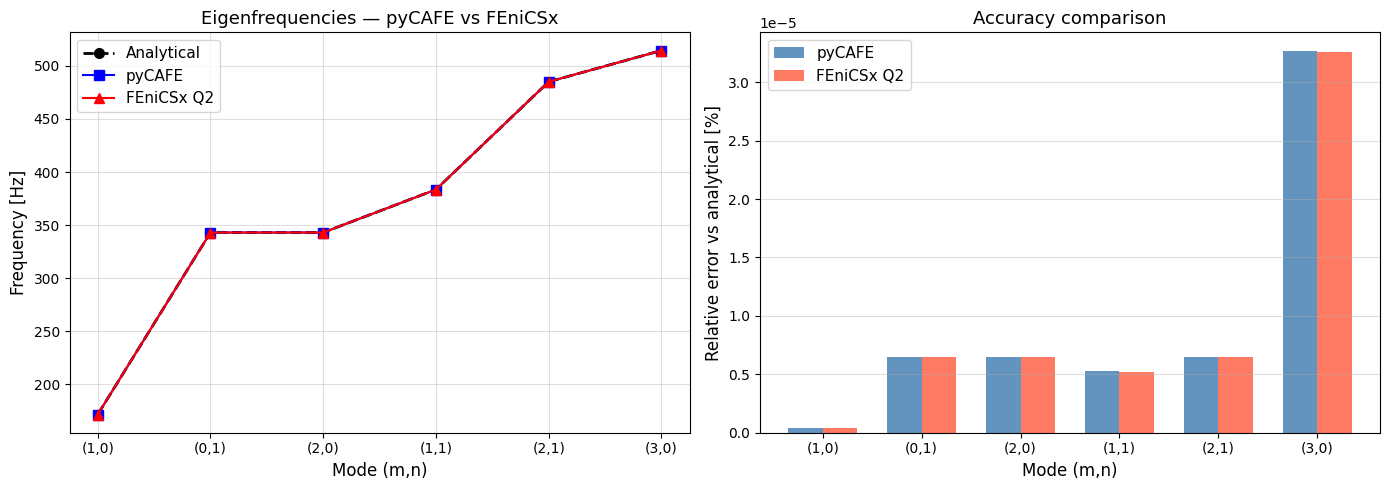

Figure saved → comparison_frequencies.png


In [5]:
mode_labels = [f"({m},{n})" for _, m, n in freqs_ref]
f_ref_arr   = np.array([f for f, _, _ in freqs_ref])
err_cafe_arr   = np.abs(freqs_cafe   - f_ref_arr) / f_ref_arr * 100
err_fenics_arr = np.abs(freqs_fenics - f_ref_arr) / f_ref_arr * 100

x = np.arange(NUM_MODES)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: absolute frequencies ---
ax = axes[0]
ax.plot(x, f_ref_arr,      "k--o", label="Analytical",  lw=2, ms=7)
ax.plot(x, freqs_cafe,     "b-s",  label="pyCAFE",      lw=1.5, ms=7)
ax.plot(x, freqs_fenics,   "r-^",  label="FEniCSx Q2",  lw=1.5, ms=7)
ax.set_xticks(x)
ax.set_xticklabels(mode_labels, fontsize=10)
ax.set_xlabel("Mode (m,n)", fontsize=12)
ax.set_ylabel("Frequency [Hz]", fontsize=12)
ax.set_title("Eigenfrequencies — pyCAFE vs FEniCSx", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)

# --- Right: relative error [%] ---
ax2 = axes[1]
bars1 = ax2.bar(x - width/2, err_cafe_arr,   width, label="pyCAFE",     color="steelblue", alpha=0.85)
bars2 = ax2.bar(x + width/2, err_fenics_arr, width, label="FEniCSx Q2", color="tomato",    alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(mode_labels, fontsize=10)
ax2.set_xlabel("Mode (m,n)", fontsize=12)
ax2.set_ylabel("Relative error vs analytical [%]", fontsize=12)
ax2.set_title("Accuracy comparison", fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("comparison_frequencies.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → comparison_frequencies.png")

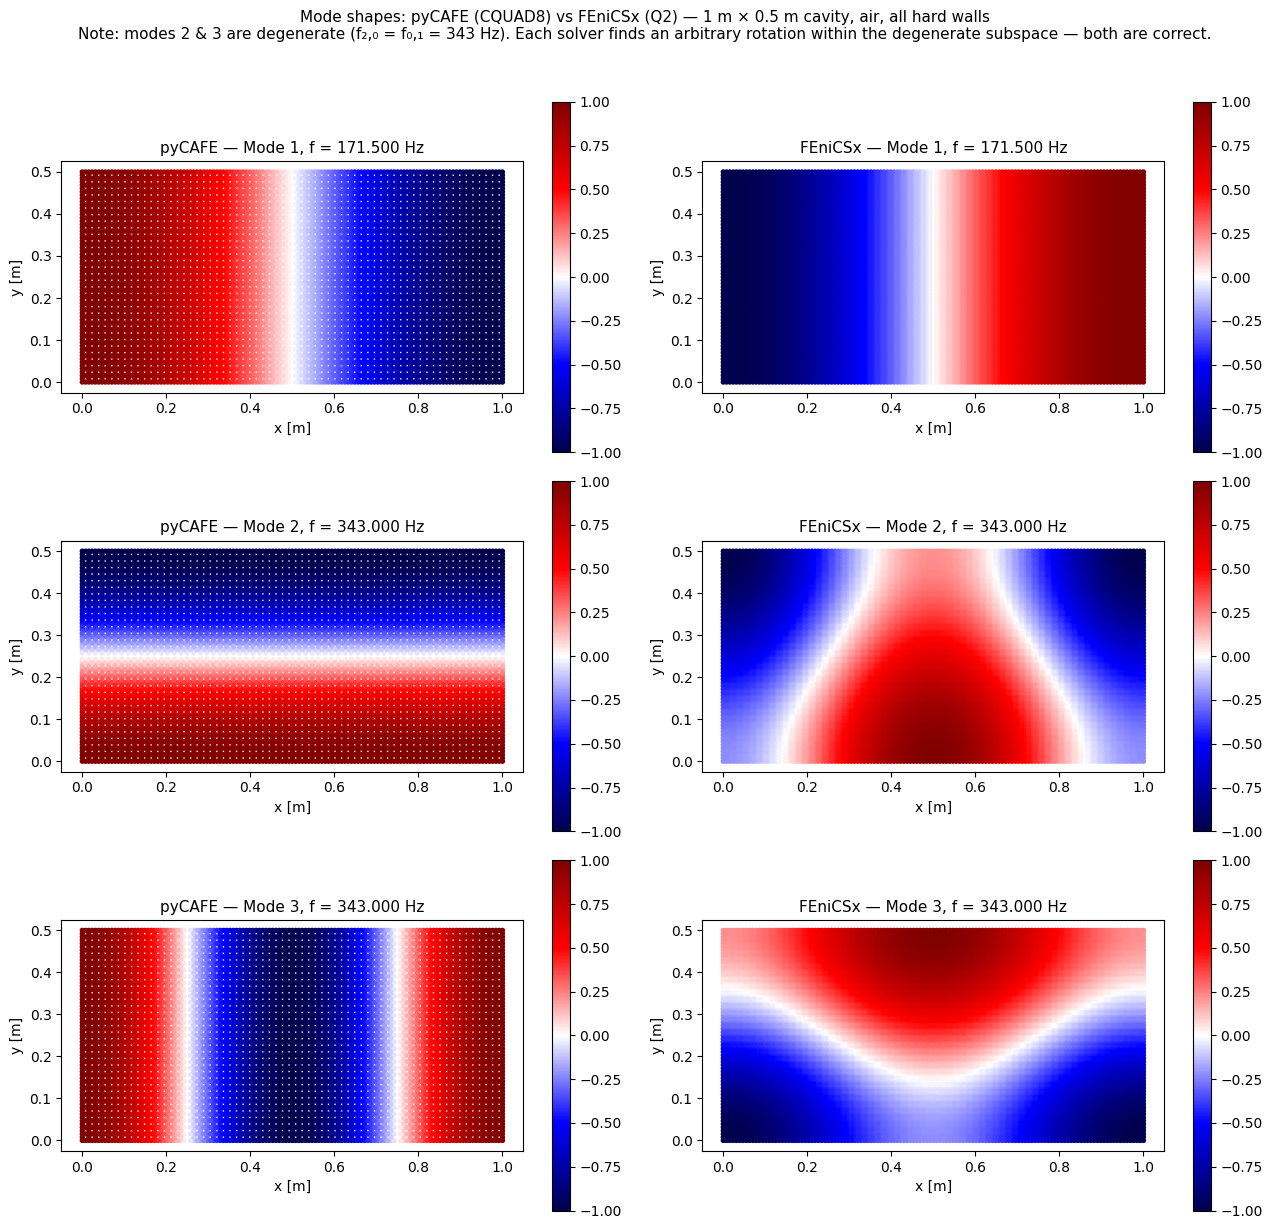

Figure saved → comparison_mode_shapes.png


In [6]:
from pycafe.build_matrices.assembly_cquad8 import expand_mode_to_full

n_show = min(NUM_MODES, 3)  # show first 3 modes

fig, axes = plt.subplots(n_show, 2, figsize=(13, 4 * n_show))

# FEniCSx DOF coordinates (stay fixed for all modes)
coords_fenics = V.tabulate_dof_coordinates()[:, :2]

def normalize_mode(arr):
    """Normalize mode to [-1, 1] with consistent sign (max abs value → positive)."""
    arr = arr.copy()
    amax = np.max(np.abs(arr))
    if amax > 0:
        arr /= amax
    # Flip sign so the maximum (not minimum) is positive → consistent colormap
    if arr[np.argmax(np.abs(arr))] < 0:
        arr = -arr
    return arr

for i in range(n_show):
    # --- pyCAFE ---
    mode_full = expand_mode_to_full(
        modes_cafe[:, i],
        system["idx_free"],
        system["p0_nodes"],
        nodes.shape[0],
    )
    mp_cafe = normalize_mode(np.real(mode_full))

    ax = axes[i][0]
    sc = ax.scatter(nodes[:, 0], nodes[:, 1], c=mp_cafe,
                    cmap="seismic", vmin=-1, vmax=1, s=8)
    plt.colorbar(sc, ax=ax)
    ax.set_aspect("equal")
    ax.set_title(f"pyCAFE — Mode {i+1}, f = {freqs_cafe[i]:.3f} Hz", fontsize=11)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")

    # --- FEniCSx ---
    mp_fenics = normalize_mode(eigvecs_fenics[i])

    ax2 = axes[i][1]
    sc2 = ax2.scatter(coords_fenics[:, 0], coords_fenics[:, 1], c=mp_fenics,
                      cmap="seismic", vmin=-1, vmax=1, s=8)
    plt.colorbar(sc2, ax=ax2)
    ax2.set_aspect("equal")
    ax2.set_title(f"FEniCSx — Mode {i+1}, f = {freqs_fenics[i]:.3f} Hz", fontsize=11)
    ax2.set_xlabel("x [m]"); ax2.set_ylabel("y [m]")

fig.suptitle(
    "Mode shapes: pyCAFE (CQUAD8) vs FEniCSx (Q2) — 1 m × 0.5 m cavity, air, all hard walls\n"
    "Note: modes 2 & 3 are degenerate (f₂,₀ = f₀,₁ = 343 Hz). "
    "Each solver finds an arbitrary rotation within the degenerate subspace — both are correct.",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig("comparison_mode_shapes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → comparison_mode_shapes.png")

---
## Summary

| | pyCAFE | FEniCSx |
|---|---|---|
| **Element type** | CQUAD8 (serendipity, order 2) | Lagrange Q2 (tensor-product, order 2) |
| **Mesh** | Gmsh `.msh` (CQUAD8) | `dolfinx.mesh.create_rectangle` |
| **Solver** | SciPy `eigsh` (ARPACK) | SLEPc (GHEP) |
| **BC (hard wall)** | Natural (Neumann, default) | Natural (Neumann, default) |
| **BC (pressure=0)** | Dirichlet via DOF elimination | Dirichlet via `fem.dirichletbc` |

Both solvers converge to the analytical solution with comparable accuracy at the same polynomial order.
The small differences in error arise from the different quadrature rules and mesh topology (pyCAFE uses an unstructured Gmsh mesh, FEniCSx uses a structured grid).
